[Home](../../README.md)

### Model Evaluation

This is a demonstration of evaluating a model.

#### Step 1

Load the required dependencies.


In [1]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('../../style_Matplotlib_charts.mplstyle')
from sklearn.linear_model import LinearRegression
import pickle

####  Step 2

Load the model for testing

In [2]:
filename = 'my_saved_model_v1.sav'
model_A = pickle.load(open(filename, 'rb'))


(Optional) Load a second model if you want to do comparative testing

In [3]:
filename = 'my_saved_model_v1.sav'
model_B = pickle.load(open(filename, 'rb'))

####  Step 3
Open and parse the test data CSV file and store the data as variable array data objects.

In [4]:
x_col = 'BMI'
testing_data = pd.read_csv('2.4.1.testing_data.csv')
x_test = np.array(testing_data[x_col]).reshape(-1,1)
y_test = np.array(testing_data['Target'])

#### Step 5

Plot the test data features, targets and linear regression model to visually evaluate the model.

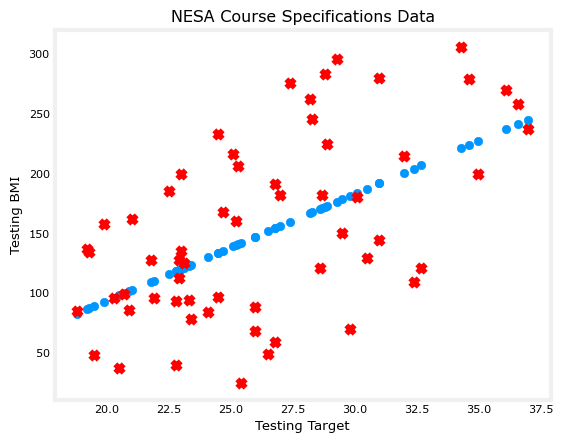

In [5]:
y_pred = model_A.predict(x_test)
plt.scatter(x_test, y_pred)
plt.scatter(x_test, y_test, marker='x', c='r')
plt.title("NESA Course Specifications Data")
plt.ylabel(f'Testing {x_col}')
plt.xlabel(f'Testing Target')
plt.show()

#### Step 6

Use the 'score' method of the `LinearRegression` class to return a score based evaluation of the models accuracy or performance.

In [6]:
test_score = model_A.score(x_test, y_test)
print(f'Training data score: {test_score}')

Training data score: 0.3184634594705118


#### Step 7

Manually calculate and evaluate the 'loss' and 'cost' of the model using the test data.

In [7]:
table = pd.DataFrame({
    testing_data.columns[0]: x_test.flatten(),  # Flatten x for easy display
    testing_data.columns[1]: y_test,
    'Predicted result':model_A.predict(x_test),
    'Loss' : abs(model_A.predict(x_test).round(2) - y_test)**2
})
print(table)
cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()

print(f"The cost or average loss of this model is {cost}")

     DoB    DoT  Predicted result        Loss
0   32.4  109.0        204.152759   9053.5225
1   25.4   25.0        141.734253  13625.8929
2   26.8   59.0        154.217954   9066.8484
3   24.5  233.0        133.709016   9858.5041
4   26.5   49.0        151.542875  10514.4516
5   31.0  144.0        191.669058   2272.4289
6   36.1  270.0        237.145398   1079.1225
7   21.8  128.0        109.633306    337.4569
8   31.0  280.0        191.669058   7802.1889
9   28.7  182.0        171.160120    117.5056
10  28.6  121.0        170.268427   2427.5329
11  23.0  135.0        120.333622    215.2089
12  25.1  216.0        139.059174   5919.7636
13  32.7  121.0        206.827838   7366.7889
14  24.1   84.0        130.142244   2128.8996
15  28.9  225.0        172.943506   2710.2436
16  22.8   40.0        118.550236   6170.1025
17  28.3  246.0        167.593348   6148.1281
18  18.8   85.0         82.882518      4.4944
19  30.1  180.0        183.643821     13.2496
20  29.5  150.0        178.293664 

You may want to do some manual predictions to understand your model.

In [8]:
print(model_A.predict([[0.1]]))
print(model_A.predict([[1]]))

[-83.86406395]
[-75.83882739]


#### Step 8

Evaluate the X axis intercept and gradient or coefficient of your model by using the getter methods to return the intercept and coefficient from my_model() object.

In [9]:
print(f'X Axis intercept: {model_A.intercept_}')
print(f'Coefficient: {model_A.coef_}')

X Axis intercept: -84.7557568988151
Coefficient: [8.91692951]


#### Step 9. Multiple Variable Linear Regression

You should be able to understand the code snippets with less guidelines.

In [10]:
filename = 'my_saved_model_v2.sav'
model_C = pickle.load(open(filename, 'rb'))

In [11]:
mx_col = ['BMI','BP','FDR']
testing_data = pd.read_csv('2.4.1.testing_data.csv')
mx_test = np.array(testing_data[mx_col])
my_test = np.array(testing_data['Target'])

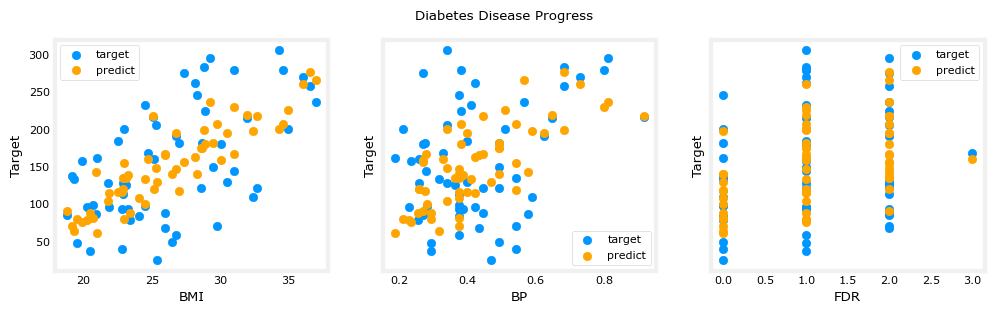

In [12]:
my_pred = model_C.predict(mx_test)

# plot predictions and targets vs original features    
fig,ax=plt.subplots(1,len(mx_col),figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(mx_test[:,i],my_test, label = 'target')
    ax[i].set_xlabel(mx_col[i])
    ax[i].scatter(mx_test[:,i],my_pred,color="orange", label = 'predict')
    ax[i].set_ylabel("Target"); ax[i].legend();
fig.suptitle("Diabetes Disease Progress")
plt.show()

In [13]:
test_score = model_C.score(mx_test, my_test)
print(f'Training data score: {test_score}')

Training data score: 0.27621341081744677


In [14]:
print(model_C.predict([[0.1,0.1,0.1]]))
print(model_C.predict([[1,0.5,1]]))

[-108.08750088]
[-36.40177216]


In [15]:
data = {col: mx_test[:, i] for i, col in enumerate(mx_col)}
data['Target'] = my_test
data['Predicted result'] = model_C.predict(mx_test)
data['Loss'] = abs(model_C.predict(mx_test).round(2) - my_test)**2
table = pd.DataFrame(data)

cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()
print(f"The cost or average loss of this model is {cost}")

print(table)

The cost or average loss of this model is 2035.8193237288137
     BMI        BP  FDR  Target  Predicted result        Loss
0   32.4  0.588235  0.0   109.0        197.559861   7842.8736
1   25.4  0.470588  0.0    25.0        129.491708  10918.1601
2   26.8  0.376471  1.0    59.0        146.544972   7663.2516
3   24.5  0.411765  1.0   233.0        133.196472   9960.0400
4   26.5  0.494118  0.0    49.0        140.802910   8427.2400
5   31.0  0.278471  1.0   144.0        166.829721    521.2089
6   36.1  0.729412  1.0   270.0        260.954737     81.9025
7   21.8  0.341176  1.0   128.0        103.867721    582.2569
8   31.0  0.800000  1.0   280.0        230.420358   2458.1764
9   28.7  0.494118  1.0   182.0        175.471848     42.6409
10  28.6  0.494118  1.0   121.0        174.704372   2883.6900
11  23.0  0.541176  2.0   135.0        155.248111    410.0625
12  25.1  0.917647  2.0   216.0        217.268568      1.6129
13  32.7  0.447059  2.0   121.0        218.217421   9451.7284
14  24.1 

In [24]:
print(f'X Axis intercept: {model_C.intercept_}')
print(f'Coefficient: {model_C.coef_}')

X Axis intercept: -122.82652991446844
Coefficient: [  7.67476034 121.93106525  17.78446479]


#### Step 10. Polynomial Linear Regression

You should be able to understand the code snippets with less guidelines.

In [35]:
model_filename = 'my_saved_model_v3.sav'
poly_filename = 'my_saved_poly_v3.pkl'
import builtins

model_D = pickle.load(open(model_filename, 'rb'))
poly = pickle.load(builtins.open(poly_filename, 'rb'))
# poly = open(poly_filename, 'rb')

In [36]:
mx_col = ['BMI']
testing_data = pd.read_csv('2.4.1.testing_data.csv')
mx_test = np.array(testing_data[mx_col])
my_test = np.array(testing_data['Target'])

In [37]:
poly_features = poly.fit_transform(mx_test)

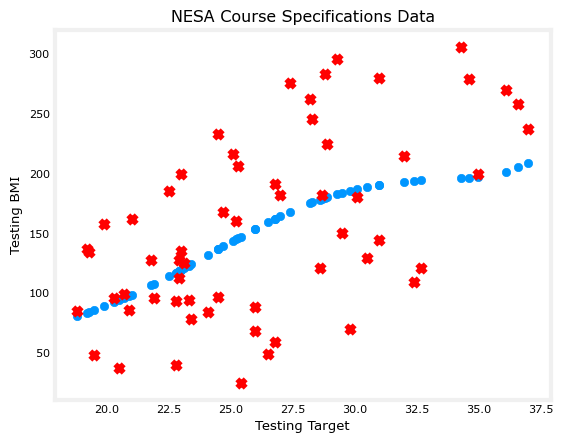

In [38]:
y_pred = model_D.predict(poly_features)

plt.scatter(x_test, y_pred)
plt.scatter(x_test, y_test, marker='x', c='r')
plt.title("NESA Course Specifications Data")
plt.ylabel(f'Testing {x_col}')
plt.xlabel(f'Testing Target')
plt.show()

In [39]:
test_score = model_D.score(poly_features, my_test)
print(f'Training data score: {test_score}')

Training data score: 0.2885513141249718


In [40]:
new_poly_feature = poly.fit_transform([[0.1]])
print(model_D.predict(new_poly_feature))

[-2130.25313693]


In [41]:
data = {col: mx_test[:, i] for i, col in enumerate(mx_col)}
data['Target'] = my_test
data['Predicted result'] = model_D.predict(poly_features)
data['Loss'] = abs(model_D.predict(poly_features).round(2) - my_test)**2
table = pd.DataFrame(data)

cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()
print(f"The cost or average loss of this model is {cost}")

print(table)

The cost or average loss of this model is 2001.1216728813563
     BMI  Target  Predicted result        Loss
0   32.4   109.0        193.863624   7201.2196
1   25.4    25.0        147.125495  14915.7369
2   26.8    59.0        162.208746  10652.3041
3   24.5   233.0        136.771303   9260.2129
4   26.5    49.0        159.131806  12128.6169
5   31.0   144.0        190.781605   2188.3684
6   36.1   270.0        201.609067   4677.1921
7   21.8   128.0        106.420556    465.6964
8   31.0   280.0        190.781605   7960.2084
9   28.7   182.0        178.839714      9.9856
10  28.6   121.0        178.106750   3261.5521
11  23.0   135.0        119.452890    241.8025
12  25.1   216.0        143.707309   5225.8441
13  32.7   121.0        194.240761   5364.0976
14  24.1    84.0        132.115288   2315.5344
15  28.9   225.0        180.253370   2002.5625
16  22.8    40.0        117.206382   5961.3841
17  28.3   246.0        175.805418   4926.6361
18  18.8    85.0         80.776613     17.8084

#### Step 11

When your model is ready for operations, move it to the [3.Operations\3.1.Deploy_Model](\3.Operations\3.1.Deploy_Model) folder.